# StressNET Inference in vivo

### Import necessary packages

In [1]:
import stressnet
from pathlib import Path
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Build StressNET model and load pretrained weights

In [3]:
stressnet.list_models()

['STRESSNET-PRETRAINED-A',
 'STRESSNET-PRETRAINED-B',
 'STRESSNET-PRETRAINED-C',
 'STRESSNET-PRETRAINED-D',
 'STRESSNET-PRETRAINED-E',
 'STRESSNET-FINETUNED-MYOSIN-88-A']

**Build the model al load pretrained weights (weights are downloaded automatically on first run)**

In [4]:
model = stressnet.load_model()  # loads 'STRESSNET-PRETRAINED-A' by default

In [5]:
model.summary()

Model: "StressNetV0.2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 edge_feats (InputLayer)        [(None, 32)]         0           []                               
                                                                                                  
 edge_feats_fc_1 (Dense)        (None, 512)          16384       ['edge_feats[0][0]']             
                                                                                                  
 edge_feats_ln_1 (LayerNormaliz  (None, 512)         1024        ['edge_feats_fc_1[0][0]']        
 ation)                                                                                           
                                                                                                  
 edge_feats_elu_1 (Activation)  (None, 512)          0           ['edge_feats_ln_1[0][

### Load microscopy images

Load a skeletonized image to generate the mesh from and myosin signal to use as a proxy for stress

In [6]:
PATH_TO_EXAMPLE_DIR = (
    Path('example_data') /
    'inference' /
    'experimental' /
    'xenopus_myosin'
    # this sample is from the evaluation split (unseen by finetuned models)
)

PATH_TO_SKELETON = PATH_TO_EXAMPLE_DIR / 'skeleton.tif'
PATH_TO_MYOSIN = PATH_TO_EXAMPLE_DIR / 'myosin.tif'

FIXED_NE = 6  # fixes the number of edges when converting skeletonized image to mesh

**Show input images**

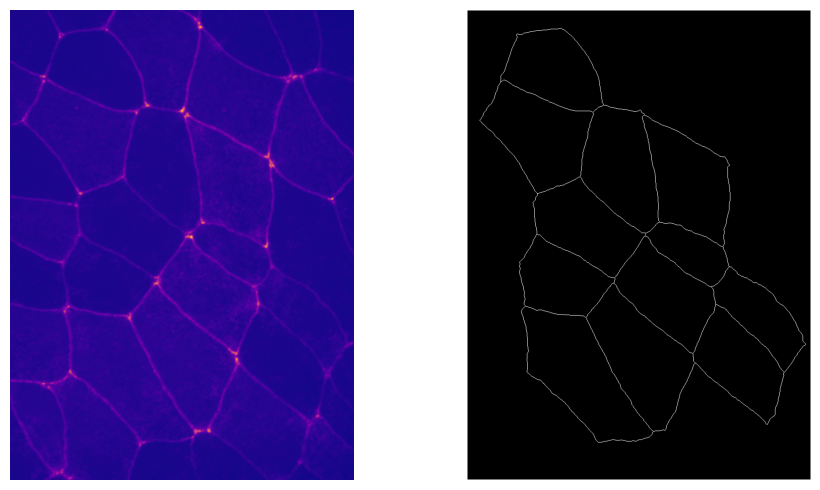

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(Image.open(PATH_TO_MYOSIN), cmap='plasma')
axes[1].imshow(Image.open(PATH_TO_SKELETON))

for ax in axes:
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Obtain a 2D Mesh from the skeletonized image and assign the normalized myosin intensity value to each cell-cell interface**

Note: passing an image as `gt_file` to `skeleton_to_graph` is optional. If provided, ForSys will assign a normalized signal intensity value to each edge as a proxy for ground-truth.

In [8]:
data = stressnet.skeleton_to_graph(
    src_file=PATH_TO_SKELETON,
    gt_file=PATH_TO_MYOSIN,
    fixed_ne=FIXED_NE,
    include_forsys_predictions=True,
    return_frame=True
)

print(
    f'A non-zero count:     {data["a"].nnz}\n'
    f'X shape:              {data["x"].shape}\n'
    f'E shape:              {data["e"].shape}\n'
    f'Y shape:              {data["y"].shape}\n'
    f'ForSys pred. shape:   {data["forsys_preds"].shape}'
)

Found zeros in ForSys predictions which will be ignored in mean normalization. These values should be masked-out when calculating metrics to obtain accurate results.


A non-zero count:     66
X shape:              (22, 6)
E shape:              (66, 16, 2)
Y shape:              (22,)
ForSys pred. shape:   (22,)


**Check if any nodes had to be removed for being disconnected from the graph**

In [9]:
removed = data.get('removed_nodes', [])
detail = f': {removed}' if (len(removed) > 0) else ''
print(f'Removed {len(removed)} nodes{detail}')

Removed 0 nodes


**Plot the tissue mesh and normalized myosin signal intensity map**

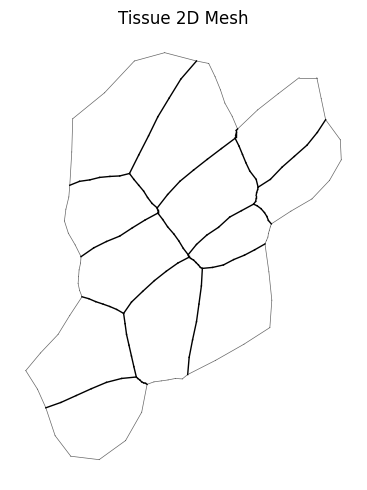

In [10]:
stressnet.plot_with_force(
    data['frame'],
    force_to_plot=None,
    figsize=(5, 5),
    title='Tissue 2D Mesh',
    plot_kwargs=dict(linewidth=1, color='black')
)

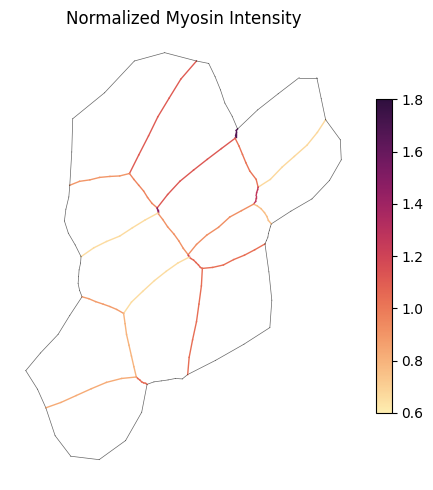

In [11]:
stressnet.plot_with_force(
    data['frame'],
    force_to_plot='gt',
    figsize=(5, 5),
    cbar=True,
    title='Normalized Myosin Intensity',
    plot_kwargs=dict(linewidth=1)
)

**Run inference with StressNET (pretrained)**

In [12]:
# single prediction mode
stressnet_preds = stressnet.predict(
    model,
    data
)

print(f'StressNET (single prediction) shape: {stressnet_preds.shape}')

StressNET (single prediction) shape: (22,)


**Load the weights of the same base model "A", finetuned on 88 Xenopus-myosin samples**

In [13]:
del model  # cleanup
finetuned_model = stressnet.load_model('STRESSNET-FINETUNED-MYOSIN-88-A')

In [14]:
# single prediction mode
stressnet_ft_preds = stressnet.predict(
    finetuned_model,
    data
)

print(f'StressNET (finetuned, single prediction) shape: {stressnet_ft_preds.shape}')

StressNET (finetuned, single prediction) shape: (22,)


**Compare results with ForSys**

In [15]:
for method, predictions in [
    ('ForSys', data['forsys_preds']),
    ('StressNET (single prediction)', stressnet_preds),
    ('StressNET (finetuned, single prediction)', stressnet_ft_preds)
]:
    r, r2, mape, score = stressnet.calculate_metrics(data['y'], predictions)
    print(
        f'{method} Predictions vs Ground Truth Tensions:\n'
        f'  Pearson R:   {r:.3f}\n'
        f'  R^2:         {r2:.3f}\n'
        f'  MAPE:        {mape:.2f}%\n'
        f'  Score:       {score:.1f}\n',
        end='\n\n'
    )

ForSys Predictions vs Ground Truth Tensions:
  Pearson R:   -0.017
  R^2:         -6.287
  MAPE:        56.23%
  Score:       2.4


StressNET (single prediction) Predictions vs Ground Truth Tensions:
  Pearson R:   0.332
  R^2:         -1.346
  MAPE:        31.30%
  Score:       4.6


StressNET (finetuned, single prediction) Predictions vs Ground Truth Tensions:
  Pearson R:   0.765
  R^2:         0.578
  MAPE:        14.08%
  Score:       13.2




**Plot predictions from base and finetuned model**

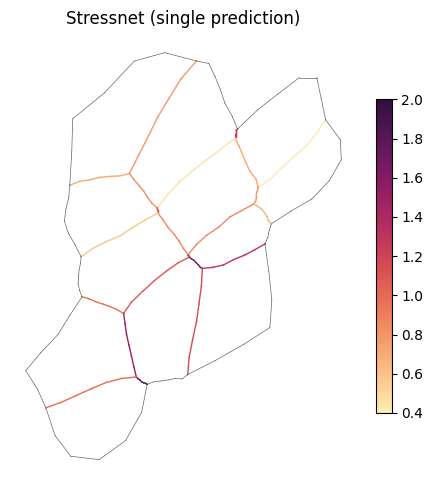

In [16]:
frame_with_stressnet_preds = stressnet.frame_with_predicted_tensions(
    data['frame'],
    stressnet_preds
)

stressnet.plot_with_force(
    frame_with_stressnet_preds,
    force_to_plot='stress',
    figsize=(5, 5),
    cbar=True,
    title='Stressnet (single prediction)',
    plot_kwargs=dict(linewidth=1)
)

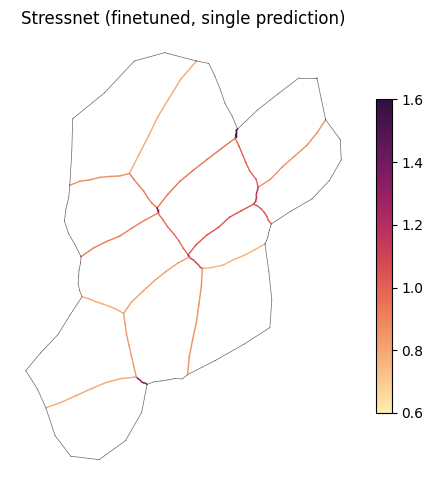

In [17]:
frame_with_stressnet_ft_preds = stressnet.frame_with_predicted_tensions(
    data['frame'],
    stressnet_ft_preds
)

stressnet.plot_with_force(
    frame_with_stressnet_ft_preds,
    force_to_plot='stress',
    figsize=(5, 5),
    cbar=True,
    title='Stressnet (finetuned, single prediction)',
    plot_kwargs=dict(linewidth=1)
)